In [2]:


import numpy as np
import xarray as xr
import metpy.calc as mpcalc
import time
import os
import glob
from metpy.units import units
from typing import Tuple, List, Dict
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from scipy import signal, fft
import cmaps
from pywk99.spectrum.spectrum import get_cross_spectrum
from pywk99.timeseries import remove_seasonal_cycle
from pywk99.timeseries import remove_linear_trend
from pywk99.waves import plot_dispersion_relations

FIG_SAVE_DIR = "./figures/cross_spectrum/"

# 创建必要的目录
for d in [ FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)


EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

In [3]:
# ============ 快速加载850hPa散度数据 ============

def load_850hpa_divergence(experiment='cntl', data_dir='processed_data'):
    """
    快速加载已保存的850hPa散度数据
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    
    Returns:
    --------
    xr.DataArray
        散度数据
    
    Example:
    --------
    >>> div_cntl = load_850hpa_divergence('cntl')
    >>> div_p4k = load_850hpa_divergence('p4k')
    >>> div_4co2 = load_850hpa_divergence('4co2')
    """
    # 构建文件路径
    file_pattern = os.path.join(data_dir, f'divergence_850hpa_lev*_{experiment}.nc')
    files = glob.glob(file_pattern)
    
    if not files:
        raise FileNotFoundError(f"未找到实验 {experiment} 的散度数据文件: {file_pattern}")
    
    if len(files) > 1:
        print(f"⚠️ 找到多个文件，使用第一个: {files[0]}")
    
    file_path = files[0]
    print(f"📂 加载数据: {file_path}")
    
    # 加载数据
    ds = xr.open_dataset(file_path)
    div = ds['divergence']
    
    print(f"✅ 数据加载成功")
    print(f"   形状: {div.shape}")
    print(f"   维度: {div.dims}")
    print(f"   时间范围: {div.time.values[0]} to {div.time.values[-1]}")
    print(f"   空间范围: lat [{div.lat.min().values:.1f}, {div.lat.max().values:.1f}], "
          f"lon [{div.lon.min().values:.1f}, {div.lon.max().values:.1f}]")
    
    return div


def load_all_850hpa_divergence(data_dir='processed_data'):
    """
    加载所有实验的850hPa散度数据
    
    Returns:
    --------
    dict
        包含所有实验散度数据的字典
    """
    print("\n" + "="*60)
    print("加载所有850hPa散度数据")
    print("="*60)
    
    experiments = ['cntl', 'p4k', '4co2']
    divergence_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            div = load_850hpa_divergence(exp, data_dir)
            divergence_data[exp] = div
        except FileNotFoundError as e:
            print(f"❌ {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(divergence_data)} 个实验的数据")
    print(f"{'='*60}")
    
    return divergence_data


# 使用示例
print("\n" + "="*60)
print("使用示例:")
print("="*60)
print("""
# 加载单个实验的散度数据:
div_cntl = load_850hpa_divergence('cntl')

# 加载所有实验的散度数据:


# 计算时间平均:
div_mean = all_div['cntl'].mean(dim='time')

# 计算区域平均:
div_tropical_mean = all_div['cntl'].mean(dim=['lat', 'lon'])
""")
all_div = load_all_850hpa_divergence()

# 访问特定实验:
div_cntl = all_div['cntl']
div_p4k = all_div['p4k']
div_4co2 = all_div['4co2']


使用示例:

# 加载单个实验的散度数据:
div_cntl = load_850hpa_divergence('cntl')

# 加载所有实验的散度数据:


# 计算时间平均:
div_mean = all_div['cntl'].mean(dim='time')

# 计算区域平均:
div_tropical_mean = all_div['cntl'].mean(dim=['lat', 'lon'])


加载所有850hPa散度数据

加载 CNTL...
📂 加载数据: processed_data/divergence_850hpa_lev81_cntl.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   空间范围: lat [-14.0, 14.0], lon [0.0, 358.0]

加载 P4K...
📂 加载数据: processed_data/divergence_850hpa_lev81_p4k.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   空间范围: lat [-14.0, 14.0], lon [0.0, 358.0]

加载 4CO2...
📂 加载数据: processed_data/divergence_850hpa_lev81_4co2.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000
   空间范围: lat [-14.0, 14.0], lon [0.0, 358.0]

✅ 成功加载 3 个实验的数据


In [4]:
# ============ 加载降水数据 ============

def load_precipitation_data(experiment='cntl', data_dir='cache/kelvin_wave'):
    """
    加载降水数据
    
    Parameters:
    -----------
    experiment : str
        实验名称，可选: 'cntl', 'p4k', '4co2'
    data_dir : str
        数据目录
    
    Returns:
    --------
    xr.DataArray
        降水数据
    """
    # 构建文件路径
    file_path = os.path.join(data_dir, f'kelvin_pr_{experiment}.nc')
    
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"未找到实验 {experiment} 的降水数据文件: {file_path}")
    
    print(f"📂 加载数据: {file_path}")
    
    # 加载数据 - 使用 open_dataarray 因为数据是以 DataArray 形式保存的
    pr = xr.open_dataarray(file_path)
    
    print(f"✅ 数据加载成功")
    print(f"   形状: {pr.shape}")
    print(f"   维度: {pr.dims}")
    print(f"   时间范围: {pr.time.values[0]} to {pr.time.values[-1]}")
    
    return pr


def load_all_precipitation_data(data_dir='cache/kelvin_wave'):
    """
    加载所有实验的降水数据
    
    Returns:
    --------
    dict
        包含所有实验降水数据的字典
    """
    print("\n" + "="*60)
    print("加载所有降水数据")
    print("="*60)
    
    experiments = ['cntl', 'p4k', '4co2']
    pr_data = {}
    
    for exp in experiments:
        try:
            print(f"\n加载 {exp.upper()}...")
            pr = load_precipitation_data(exp, data_dir)
            pr_data[exp] = pr
        except Exception as e:
            print(f"❌ 错误: {e}")
    
    print(f"\n{'='*60}")
    print(f"✅ 成功加载 {len(pr_data)} 个实验的数据")
    print(f"{'='*60}")
    
    return pr_data


# 加载所有实验的降水数据
all_pr = load_all_precipitation_data()

# 访问特定实验:
pr_cntl = all_pr['cntl']
pr_p4k = all_pr['p4k']
pr_4co2 = all_pr['4co2']

print("\n数据加载完成！")
print(f"CNTL 降水数据形状: {pr_cntl.shape}")
print(f"P4K 降水数据形状: {pr_p4k.shape}")
print(f"4CO2 降水数据形状: {pr_4co2.shape}")


加载所有降水数据

加载 CNTL...
📂 加载数据: cache/kelvin_wave/kelvin_pr_cntl.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000

加载 P4K...
📂 加载数据: cache/kelvin_wave/kelvin_pr_p4k.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000

加载 4CO2...
📂 加载数据: cache/kelvin_wave/kelvin_pr_4co2.nc
✅ 数据加载成功
   形状: (5114, 15, 180)
   维度: ('time', 'lat', 'lon')
   时间范围: 1980-01-01T00:00:00.000000000 to 1993-12-31T00:00:00.000000000

✅ 成功加载 3 个实验的数据

数据加载完成！
CNTL 降水数据形状: (5114, 15, 180)
P4K 降水数据形状: (5114, 15, 180)
4CO2 降水数据形状: (5114, 15, 180)



计算 CNTL 实验的交叉谱


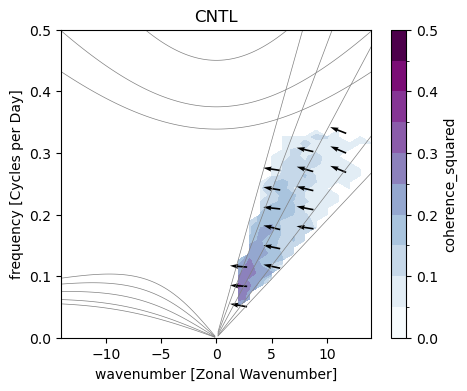

图像已保存: ./figures/cross_spectrum/cross_spectrum_pr_div_850hpa_cntl.png

计算 P4K 实验的交叉谱


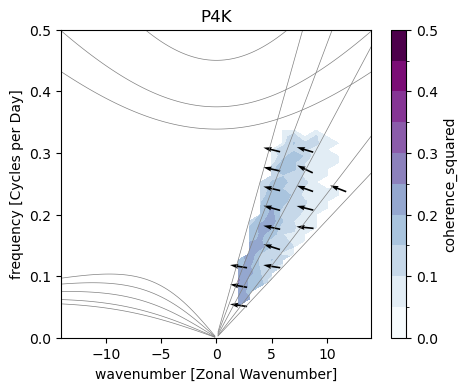

图像已保存: ./figures/cross_spectrum/cross_spectrum_pr_div_850hpa_p4k.png

计算 4CO2 实验的交叉谱


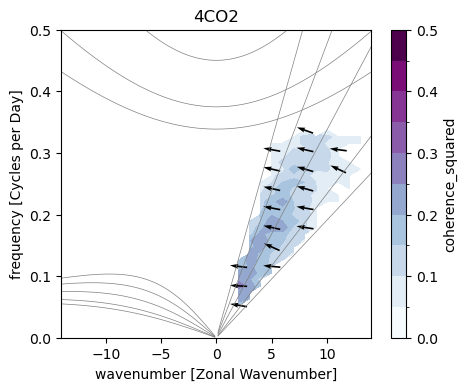

图像已保存: ./figures/cross_spectrum/cross_spectrum_pr_div_850hpa_4co2.png


In [6]:
for exp_name in ['cntl', 'p4k', '4co2']:
    print(f"\n{'='*60}")
    print(f"计算 {exp_name.upper()} 实验的交叉谱")
    print(f"{'='*60}")
    
    # 获取对应的降水和散度数据
    pr_raw = all_pr[exp_name]
    div_raw = all_div[exp_name]
    variables = xr.Dataset({"olr": pr_raw, "slp": div_raw})
    variables = variables.sortby("lat")
    # print(variables)
    variables_normalized = remove_linear_trend(variables)
    variables_normalized = remove_seasonal_cycle(variables_normalized)
    window_length = "96D"
    overlap_length = "60D"
    data_frequency = "1D"
    taper_alpha = 0.1
    symmetric_spectrum = get_cross_spectrum(
        variables_normalized,
        "symmetric",
        data_frequency,
        window_length,
        overlap_length,
        taper_alpha=taper_alpha,
    )
    COHERENCE_THRESHOLD = 0.05
    coh2 = symmetric_spectrum.coherence_squared
    coh2 = coh2.where(coh2 > COHERENCE_THRESHOLD, drop=True)
    u = xr.apply_ufunc(np.real, symmetric_spectrum.cross) / np.abs(symmetric_spectrum.cross)
    v = xr.apply_ufunc(np.imag, symmetric_spectrum.cross) / np.abs(symmetric_spectrum.cross)
    u = u.where(coh2 > COHERENCE_THRESHOLD, drop=True)
    v = v.where(coh2 > COHERENCE_THRESHOLD, drop=True)
    fig, ax = plt.subplots(1 , 1, figsize=(5, 4))
    coh2.plot.contourf(ax=ax, levels=np.linspace(0, 0.5, 11), cmap=cmaps.MPL_BuPu)
    stride = 3
    ax.quiver(u.wavenumber[::stride],
            u.frequency[::stride],
            u[::stride,::stride],
            v[::stride,::stride],
            angles="uv", pivot='mid', units='x', width=0.15)
    plot_dispersion_relations("symmetric", ax, w_max=0.5)
    plt.title(f"{exp_name.upper()}")
    fig_path = os.path.join(FIG_SAVE_DIR, f"cross_spectrum_pr_div_850hpa_{exp_name}.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"图像已保存: {fig_path}")    